# Assignment B — Healthcare Marketing Data Analysis

### Objective

Analyze physician marketing outreach data to calculate:

- Reach
- Frequency
- Engagement

The analysis evaluates these metrics overall and across:

- Communication Source
- Channel
- Month

The objective is to identify meaningful patterns and provide
data-driven recommendations for improving physician engagement.

**Candidate:** Harika Adepu


In [1]:
!pip install -q pandas openpyxl matplotlib --break-system-packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load dataset

In [3]:
marketing_df = pd.read_excel(
    "Marketing Data - Hiring.xlsx"
)

print("Shape:", marketing_df.shape)

display(marketing_df.head())

Shape: (100040, 9)


,Communication Source,Source Channel Name,Therapeutic Area,Device,Source Device Name,Activity,Count of Activity Metrics,Activity Date,Physician ID
0,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-01-24,3049662215
1,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-02-12,3049662215
2,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-03-01,3049662215
3,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-03-05,3049662215
4,Internal CRM Tool,Email,HR+/HER2-,UNKNOWN,Unspecified,Sent,NaN,2024-03-05,3049662215


## Inspect

In [4]:
marketing_df.info()
display(marketing_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100040 entries, 0 to 100039
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Communication Source       100040 non-null  object        
 1   Source Channel Name        100040 non-null  object        
 2   Therapeutic Area           95818 non-null   object        
 3   Device                     100040 non-null  object        
 4   Source Device Name         100040 non-null  object        
 5   Activity                   100040 non-null  object        
 6   Count of Activity Metrics  6126 non-null    float64       
 7   Activity Date              100040 non-null  datetime64[ns]
 8   Physician ID               100040 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 6.9+ MB


Communication Source             0
Source Channel Name              0
Therapeutic Area              4222
Device                           0
Source Device Name               0
Activity                         0
Count of Activity Metrics    93914
Activity Date                    0
Physician ID                     0
dtype: int64

## Clean column names

In [5]:
marketing_df.columns = (
    marketing_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(marketing_df.columns.tolist())

['Communication_Source', 'Source_Channel_Name', 'Therapeutic_Area', 'Device', 'Source_Device_Name', 'Activity', 'Count_of_Activity_Metrics', 'Activity_Date', 'Physician_ID']


## Duplicate analysis

In [6]:
duplicate_count = marketing_df.duplicated().sum()

print(
    "Exact duplicate rows:",
    duplicate_count
)

Exact duplicate rows: 4275


In [7]:
marketing_df = marketing_df.drop_duplicates()

print(
    "Shape after removing duplicates:",
    marketing_df.shape
)

Shape after removing duplicates: (95765, 9)


### Duplicate Handling

The raw dataset contained exact duplicate rows. These were removed because
duplicated records could artificially inflate activity-based marketing metrics.


## Date processing

In [8]:
marketing_df["Activity_Date"] = pd.to_datetime(
    marketing_df["Activity_Date"]
)

In [9]:
marketing_df["Month"] = (
    marketing_df["Activity_Date"]
    .dt.to_period("M")
    .astype(str)
)

## Inspect categorical variables

In [10]:
for column in [
    "Communication_Source",
    "Source_Channel_Name",
    "Therapeutic_Area",
    "Device",
    "Source_Device_Name",
    "Activity"
]:

    print("\n", column)

    display(
        marketing_df[column]
        .value_counts()
        .head(20)
    )


 Communication_Source


Communication_Source
Internal CRM Tool    68214
Medspace360           9497
Sales Reps            8604
Oncopulse             4899
Remission Report      4551
Name: count, dtype: int64


 Source_Channel_Name


Source_Channel_Name
Email          81369
Email Alert     9497
SMS             4899
Name: count, dtype: int64


 Therapeutic_Area


...

Device
UNKNOWN         93366
DESKTOP          2245
MOBILE             97
WEB_BROWSER        42
APP/SOFTWARE       13
TABLET              2
Name: count, dtype: int64


 Source_Device_Name


Source_Device_Name
Unspecified    93437
Desktop         2082
PC               139
iPhone            56
Smart Phone       25
Macintosh         24
Tablet             2
Name: count, dtype: int64


 Activity


Activity
Sent           59650
Open           16434
Delivered      14798
Bounce          4494
Click            318
Unsubscribe       61
Hard Bounce       10
Name: count, dtype: int64

## Activity distribution

In [11]:
activity_counts = (
    marketing_df["Activity"]
    .value_counts()
)

display(activity_counts)

Activity
Sent           59650
Open           16434
Delivered      14798
Bounce          4494
Click            318
Unsubscribe       61
Hard Bounce       10
Name: count, dtype: int64

In [12]:
activity_summary = (
    marketing_df
    .groupby("Activity")["Count_of_Activity_Metrics"]
    .agg(["count", "sum"])
    .reset_index()
)

display(activity_summary)

,Activity,count,sum
0,Bounce,0,0.0
1,Click,17,17.0
2,Delivered,0,0.0
3,Hard Bounce,0,0.0
4,Open,5717,5742.0
5,Sent,0,0.0
6,Unsubscribe,0,0.0


This is important because it shows the nature of the marketing events.

## Metric Definitions

### Reach

Reach is defined as the number of unique physicians represented in the
marketing activity data.

`Reach = Number of unique Physician IDs`

### Frequency

Frequency measures the average number of outbound contact events per
reached physician.

`Frequency = Total contact events / Unique physicians reached`

### Engagement

Engagement represents physician interaction with marketing communications.

For this analysis, interaction activities include:

- Open
- Click
- Unsubscribe

Delivery and transmission events such as Sent, Delivered, Bounce and Hard Bounce
are treated as communication/delivery events rather than physician engagement.


## Metric Calculation Methodology

The dataset contains different activity labels across communication sources.

For outbound contact:

- `Sent` is treated as one contact event.
- `Delivered` is treated as one contact event when a source does not separately record `Sent`.
- `Open` and `Click` represent physician engagement.
- `Unsubscribe` is recorded separately as a negative engagement signal.
- `Bounce` and `Hard Bounce` are delivery failures and are not counted as physician engagement.

The `Count_of_Activity_Metrics` field is used only where a valid activity count is available. For event-level records where this field is missing, the row itself represents one recorded activity event.

Therefore, Frequency is calculated as:

`Frequency = Total outbound contact events / Unique physicians reached`

This source-aware approach avoids incorrectly assigning zero frequency to sources that use `Delivered` instead of `Sent`.

### Clean activity counts

In [13]:
# Ensure the activity count column is numeric.
marketing_df["Count_of_Activity_Metrics"] = pd.to_numeric(
    marketing_df["Count_of_Activity_Metrics"],
    errors="coerce"
)

# Create a usable activity count.
# If an explicit activity count exists, use it.
# Otherwise, treat the row as one recorded activity event.
marketing_df["Activity_Count"] = (
    marketing_df["Count_of_Activity_Metrics"]
    .fillna(1)
)

display(
    marketing_df[
        [
            "Activity",
            "Count_of_Activity_Metrics",
            "Activity_Count"
        ]
    ].head(20)
)

,Activity,Count_of_Activity_Metrics,Activity_Count
0,Sent,NaN,1.0
1,Sent,NaN,1.0
2,Sent,NaN,1.0
3,Sent,NaN,1.0
5,Delivered,NaN,1.0
6,Delivered,NaN,1.0
7,Open,NaN,1.0
8,Open,NaN,1.0
9,Delivered,NaN,1.0
10,Delivered,NaN,1.0


### Define event types

In [14]:
# Outbound communication/contact events
contact_activities = [
    "Sent",
    "Delivered"
]

# Positive interaction signals
positive_engagement_activities = [
    "Open",
    "Click"
]

# Negative engagement signal
negative_engagement_activities = [
    "Unsubscribe"
]

# Delivery failures
failure_activities = [
    "Bounce",
    "Hard Bounce"
]

print("Contact activities:", contact_activities)
print("Positive engagement:", positive_engagement_activities)
print("Negative engagement:", negative_engagement_activities)
print("Delivery failures:", failure_activities)

Contact activities: ['Sent', 'Delivered']
Positive engagement: ['Open', 'Click']
Negative engagement: ['Unsubscribe']
Delivery failures: ['Bounce', 'Hard Bounce']


### Create metric columns

In [15]:
marketing_df["Contact_Event"] = np.where(
    marketing_df["Activity"].isin(contact_activities),
    marketing_df["Activity_Count"],
    0
)

marketing_df["Positive_Engagement_Event"] = np.where(
    marketing_df["Activity"].isin(positive_engagement_activities),
    marketing_df["Activity_Count"],
    0
)

marketing_df["Negative_Engagement_Event"] = np.where(
    marketing_df["Activity"].isin(negative_engagement_activities),
    marketing_df["Activity_Count"],
    0
)

marketing_df["Engagement_Event"] = (
    marketing_df["Positive_Engagement_Event"]
    + marketing_df["Negative_Engagement_Event"]
)

marketing_df["Delivery_Failure_Event"] = np.where(
    marketing_df["Activity"].isin(failure_activities),
    marketing_df["Activity_Count"],
    0
)

### Validate the event mapping

In [16]:
event_summary = (
    marketing_df
    .groupby("Activity")
    .agg(
        Records=("Activity", "size"),
        Activity_Count=("Activity_Count", "sum"),
        Contact_Events=("Contact_Event", "sum"),
        Positive_Engagement=("Positive_Engagement_Event", "sum"),
        Negative_Engagement=("Negative_Engagement_Event", "sum"),
        Delivery_Failures=("Delivery_Failure_Event", "sum")
    )
    .reset_index()
)

display(event_summary)

,Activity,Records,Activity_Count,Contact_Events,Positive_Engagement,Negative_Engagement,Delivery_Failures
0,Bounce,4494,4494.0,0.0,0.0,0.0,4494.0
1,Click,318,318.0,0.0,318.0,0.0,0.0
2,Delivered,14798,14798.0,14798.0,0.0,0.0,0.0
3,Hard Bounce,10,10.0,0.0,0.0,0.0,10.0
4,Open,16434,16459.0,0.0,16459.0,0.0,0.0
5,Sent,59650,59650.0,59650.0,0.0,0.0,0.0
6,Unsubscribe,61,61.0,0.0,0.0,61.0,0.0


## Overall Metrics

In [17]:
overall_reach = marketing_df["Physician_ID"].nunique()

overall_contact_events = marketing_df["Contact_Event"].sum()

overall_frequency = (
    overall_contact_events / overall_reach
    if overall_reach > 0
    else 0
)

overall_positive_engagement = (
    marketing_df["Positive_Engagement_Event"].sum()
)

overall_negative_engagement = (
    marketing_df["Negative_Engagement_Event"].sum()
)

overall_engagement = (
    overall_positive_engagement
    + overall_negative_engagement
)

overall_engagement_rate = (
    overall_engagement / overall_reach
    if overall_reach > 0
    else 0
)

overall_positive_engagement_rate = (
    overall_positive_engagement / overall_reach
    if overall_reach > 0
    else 0
)

overall_metrics = pd.DataFrame({
    "Metric": [
        "Reach",
        "Contact Events",
        "Frequency",
        "Positive Engagement",
        "Negative Engagement",
        "Total Engagement",
        "Engagement per Reach",
        "Positive Engagement per Reach"
    ],
    "Value": [
        overall_reach,
        overall_contact_events,
        round(overall_frequency, 2),
        overall_positive_engagement,
        overall_negative_engagement,
        overall_engagement,
        round(overall_engagement_rate, 3),
        round(overall_positive_engagement_rate, 3)
    ]
})

display(overall_metrics)

,Metric,Value
0,Reach,25208.000
1,Contact Events,74448.000
2,Frequency,2.950
3,Positive Engagement,16777.000
4,Negative Engagement,61.000
5,Total Engagement,16838.000
6,Engagement per Reach,0.668
7,Positive Engagement per Reach,0.666


**Why "Engagement" changed**

The assignment defines Engagement as interactions/responses. Rather than hide `Unsubscribe` inside a single positive-sounding number, this analysis reports it separately:

- `Total Engagement = Open + Click + Unsubscribe`
- `Positive Engagement = Open + Click`
- `Negative Engagement = Unsubscribe`

This is more analytically meaningful than a single blended engagement figure.

## Metric Calculation Function

In [18]:
def calculate_metrics(data):

    reach = data["Physician_ID"].nunique()

    contact_events = data["Contact_Event"].sum()

    positive_engagement = (
        data["Positive_Engagement_Event"].sum()
    )

    negative_engagement = (
        data["Negative_Engagement_Event"].sum()
    )

    engagement = (
        positive_engagement
        + negative_engagement
    )

    frequency = (
        contact_events / reach
        if reach > 0
        else 0
    )

    engagement_per_reach = (
        engagement / reach
        if reach > 0
        else 0
    )

    positive_engagement_per_reach = (
        positive_engagement / reach
        if reach > 0
        else 0
    )

    return pd.Series({
        "Reach": reach,
        "Contact_Events": contact_events,
        "Frequency": round(frequency, 2),
        "Positive_Engagement": positive_engagement,
        "Negative_Engagement": negative_engagement,
        "Engagement": engagement,
        "Engagement_per_Reach": round(
            engagement_per_reach, 3
        ),
        "Positive_Engagement_per_Reach": round(
            positive_engagement_per_reach, 3
        )
    })

## Communication Source Analysis

In [19]:
source_metrics = (
    marketing_df
    .groupby("Communication_Source")
    .apply(
        calculate_metrics,
        include_groups=False
    )
    .reset_index()
)

display(source_metrics)

,Communication_Source,Reach,Contact_Events,Frequency,Positive_Engagement,Negative_Engagement,Engagement,Engagement_per_Reach,Positive_Engagement_per_Reach
0,Internal CRM Tool,12647.0,57194.0,4.52,6466.0,60.0,6526.0,0.516,0.511
1,Medspace360,7388.0,7388.0,1.00,2109.0,0.0,2109.0,0.285,0.285
2,Oncopulse,1848.0,2456.0,1.33,2443.0,0.0,2443.0,1.322,1.322
3,Remission Report,3133.0,0.0,0.00,4576.0,0.0,4576.0,1.461,1.461
4,Sales Reps,7420.0,7410.0,1.00,1183.0,1.0,1184.0,0.160,0.159


## Channel Analysis

In [20]:
channel_metrics = (
    marketing_df
    .groupby("Source_Channel_Name")
    .apply(
        calculate_metrics,
        include_groups=False
    )
    .reset_index()
)

display(channel_metrics)

,Source_Channel_Name,Reach,Contact_Events,Frequency,Positive_Engagement,Negative_Engagement,Engagement,Engagement_per_Reach,Positive_Engagement_per_Reach
0,Email,22092.0,64604.0,2.92,12225.0,61.0,12286.0,0.556,0.553
1,Email Alert,7388.0,7388.0,1.00,2109.0,0.0,2109.0,0.285,0.285
2,SMS,1848.0,2456.0,1.33,2443.0,0.0,2443.0,1.322,1.322


## Monthly Analysis

In [21]:
monthly_metrics = (
    marketing_df
    .groupby("Month")
    .apply(
        calculate_metrics,
        include_groups=False
    )
    .reset_index()
)

display(monthly_metrics)

,Month,Reach,Contact_Events,Frequency,Positive_Engagement,Negative_Engagement,Engagement,Engagement_per_Reach,Positive_Engagement_per_Reach
0,2024-01,23480.0,25794.0,1.10,9412.0,21.0,9433.0,0.402,0.401
1,2024-02,10284.0,14782.0,1.44,2213.0,17.0,2230.0,0.217,0.215
2,2024-03,12568.0,33872.0,2.70,5152.0,23.0,5175.0,0.412,0.410


## Best-performing Source

A large source can naturally have more engagement simply because it reaches more physicians, so both total engagement and engagement efficiency are reported.

In [22]:
best_source_by_engagement = source_metrics.loc[
    source_metrics["Engagement"].idxmax()
]

print("Highest total engagement source:")
display(best_source_by_engagement)

best_source_by_efficiency = source_metrics.loc[
    source_metrics["Engagement_per_Reach"].idxmax()
]

print("Highest engagement efficiency source:")
display(best_source_by_efficiency)

Highest total engagement source:


Communication_Source             Internal CRM Tool
Reach                                      12647.0
Contact_Events                             57194.0
Frequency                                     4.52
Positive_Engagement                         6466.0
Negative_Engagement                           60.0
Engagement                                  6526.0
Engagement_per_Reach                         0.516
Positive_Engagement_per_Reach                0.511
Name: 0, dtype: object

Highest engagement efficiency source:


Communication_Source             Remission Report
Reach                                      3133.0
Contact_Events                                0.0
Frequency                                     0.0
Positive_Engagement                        4576.0
Negative_Engagement                           0.0
Engagement                                 4576.0
Engagement_per_Reach                        1.461
Positive_Engagement_per_Reach               1.461
Name: 3, dtype: object

## Best-performing Channel

In [23]:
best_channel_by_engagement = channel_metrics.loc[
    channel_metrics["Engagement"].idxmax()
]

print("Highest total engagement channel:")
display(best_channel_by_engagement)

best_channel_by_efficiency = channel_metrics.loc[
    channel_metrics["Engagement_per_Reach"].idxmax()
]

print("Highest engagement efficiency channel:")
display(best_channel_by_efficiency)

Highest total engagement channel:


Source_Channel_Name                Email
Reach                            22092.0
Contact_Events                   64604.0
Frequency                           2.92
Positive_Engagement              12225.0
Negative_Engagement                 61.0
Engagement                       12286.0
Engagement_per_Reach               0.556
Positive_Engagement_per_Reach      0.553
Name: 0, dtype: object

Highest engagement efficiency channel:


Source_Channel_Name                 SMS
Reach                            1848.0
Contact_Events                   2456.0
Frequency                          1.33
Positive_Engagement              2443.0
Negative_Engagement                 0.0
Engagement                       2443.0
Engagement_per_Reach              1.322
Positive_Engagement_per_Reach     1.322
Name: 2, dtype: object

## Monthly Trend Insights

In [24]:
best_month = monthly_metrics.loc[
    monthly_metrics["Engagement"].idxmax()
]

highest_reach_month = monthly_metrics.loc[
    monthly_metrics["Reach"].idxmax()
]

highest_frequency_month = monthly_metrics.loc[
    monthly_metrics["Frequency"].idxmax()
]

print("Month with highest engagement:")
display(best_month)

print("\nMonth with highest reach:")
display(highest_reach_month)

print("\nMonth with highest frequency:")
display(highest_frequency_month)

Month with highest engagement:


Month                            2024-01
Reach                            23480.0
Contact_Events                   25794.0
Frequency                            1.1
Positive_Engagement               9412.0
Negative_Engagement                 21.0
Engagement                        9433.0
Engagement_per_Reach               0.402
Positive_Engagement_per_Reach      0.401
Name: 0, dtype: object


Month with highest reach:


Month                            2024-01
Reach                            23480.0
Contact_Events                   25794.0
Frequency                            1.1
Positive_Engagement               9412.0
Negative_Engagement                 21.0
Engagement                        9433.0
Engagement_per_Reach               0.402
Positive_Engagement_per_Reach      0.401
Name: 0, dtype: object


Month with highest frequency:


Month                            2024-03
Reach                            12568.0
Contact_Events                   33872.0
Frequency                            2.7
Positive_Engagement               5152.0
Negative_Engagement                 23.0
Engagement                        5175.0
Engagement_per_Reach               0.412
Positive_Engagement_per_Reach       0.41
Name: 2, dtype: object

## Chart: Reach by Source

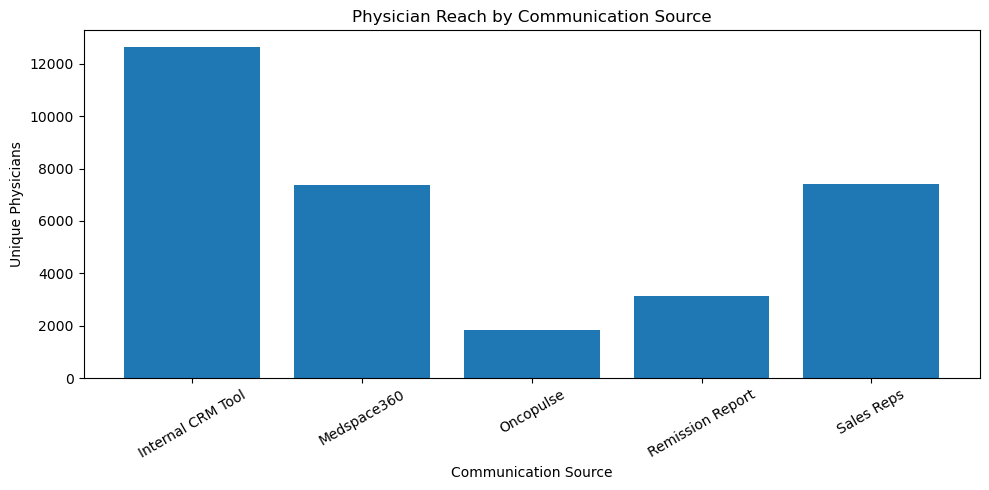

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    source_metrics["Communication_Source"],
    source_metrics["Reach"]
)

plt.title("Physician Reach by Communication Source")
plt.xlabel("Communication Source")
plt.ylabel("Unique Physicians")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Chart: Engagement by Source

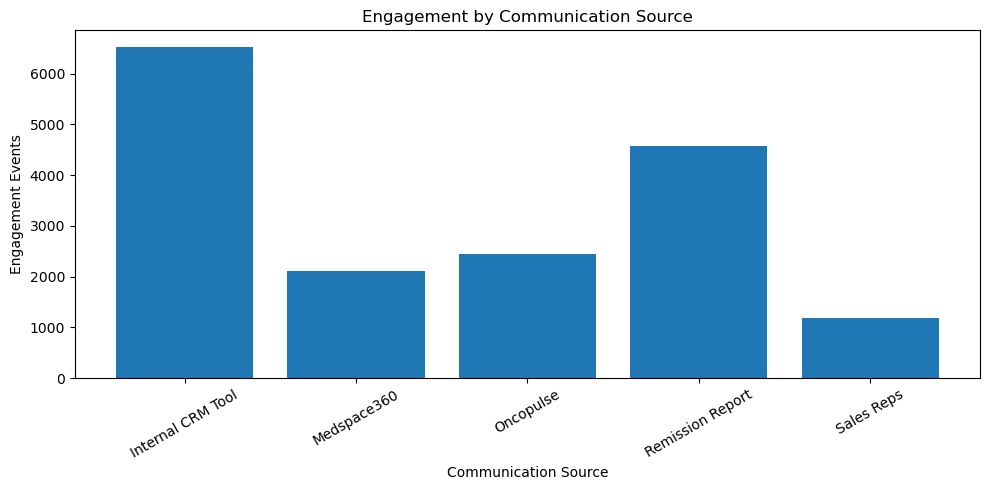

In [26]:
plt.figure(figsize=(10, 5))

plt.bar(
    source_metrics["Communication_Source"],
    source_metrics["Engagement"]
)

plt.title("Engagement by Communication Source")
plt.xlabel("Communication Source")
plt.ylabel("Engagement Events")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Chart: Engagement Efficiency by Source

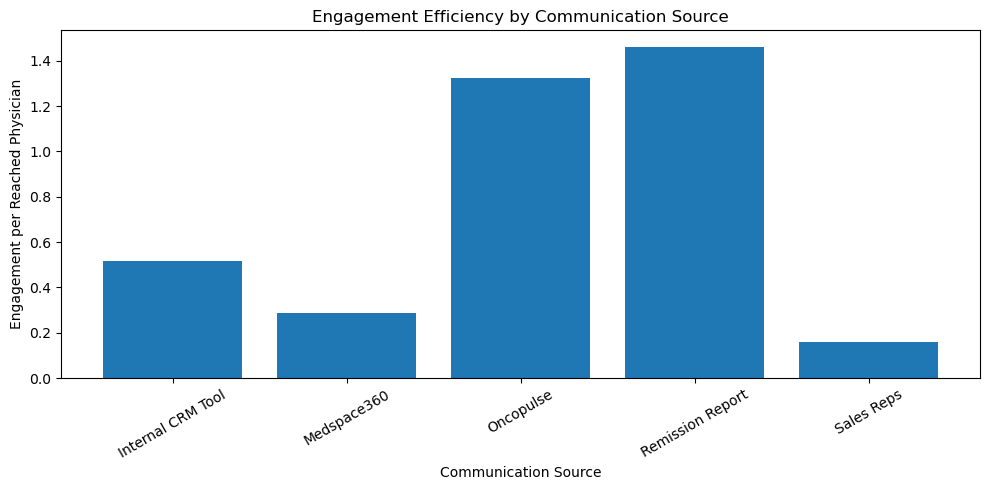

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    source_metrics["Communication_Source"],
    source_metrics["Engagement_per_Reach"]
)

plt.title("Engagement Efficiency by Communication Source")
plt.xlabel("Communication Source")
plt.ylabel("Engagement per Reached Physician")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Chart: Reach by Channel

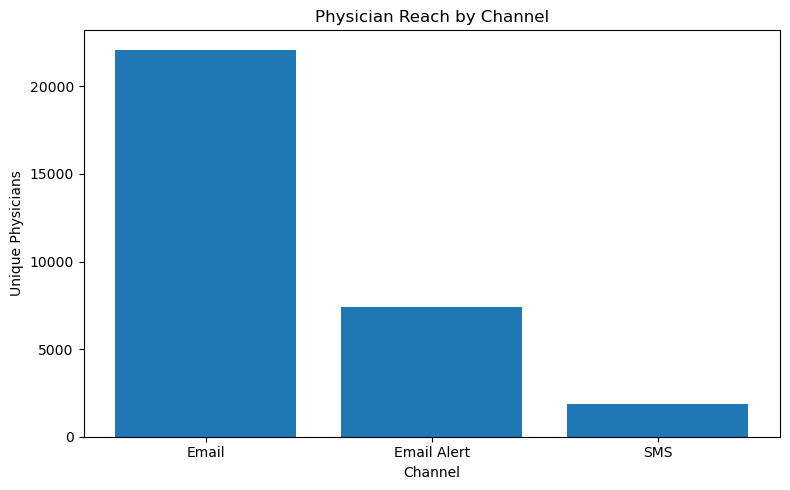

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_metrics["Source_Channel_Name"],
    channel_metrics["Reach"]
)

plt.title("Physician Reach by Channel")
plt.xlabel("Channel")
plt.ylabel("Unique Physicians")

plt.tight_layout()
plt.show()

## Chart: Engagement by Channel

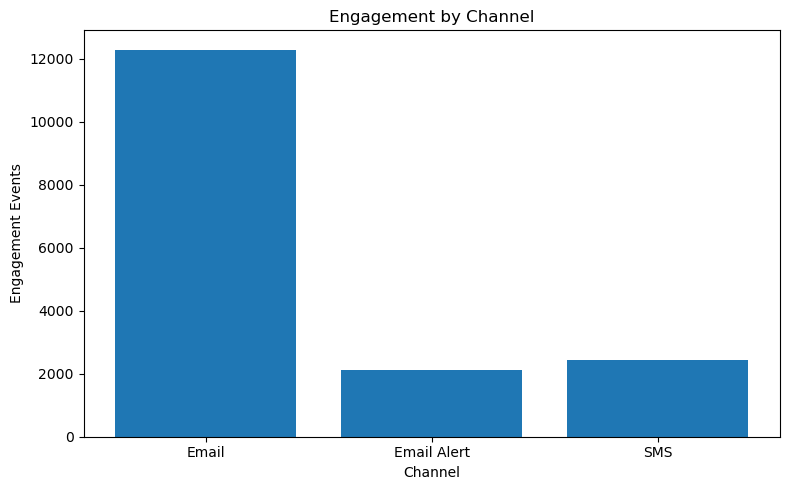

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_metrics["Source_Channel_Name"],
    channel_metrics["Engagement"]
)

plt.title("Engagement by Channel")
plt.xlabel("Channel")
plt.ylabel("Engagement Events")

plt.tight_layout()
plt.show()

## Chart: Monthly Engagement Trend

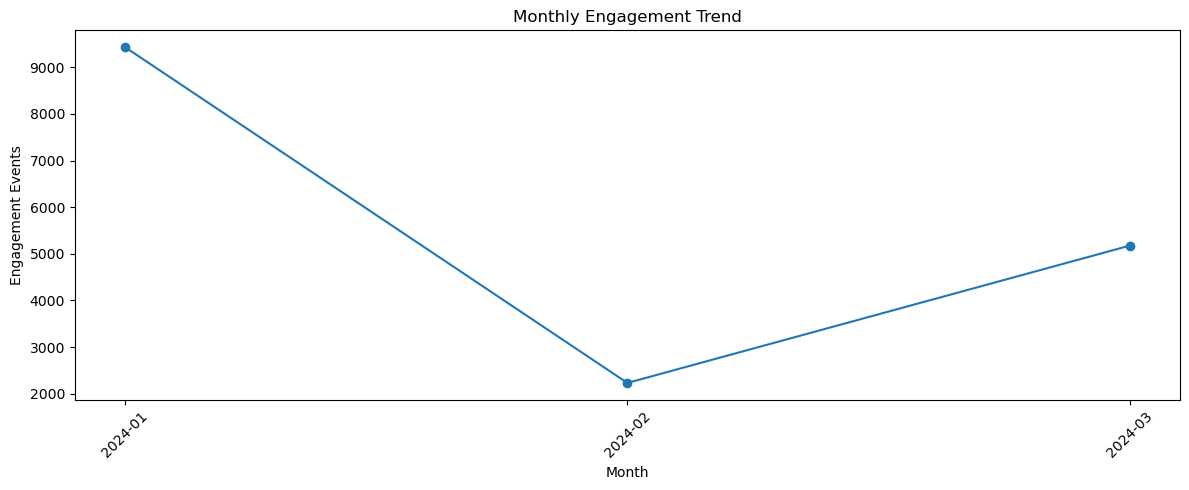

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_metrics["Month"],
    monthly_metrics["Engagement"],
    marker="o"
)

plt.title("Monthly Engagement Trend")
plt.xlabel("Month")
plt.ylabel("Engagement Events")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Chart: Monthly Reach Trend

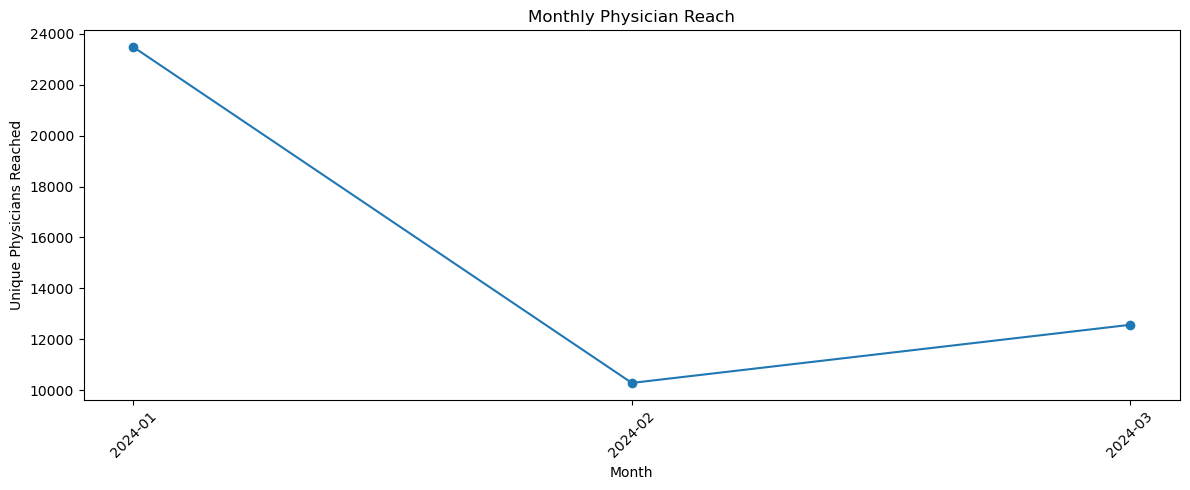

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_metrics["Month"],
    monthly_metrics["Reach"],
    marker="o"
)

plt.title("Monthly Physician Reach")
plt.xlabel("Month")
plt.ylabel("Unique Physicians Reached")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Source Observability

In [32]:
source_activity = pd.crosstab(
    marketing_df["Communication_Source"],
    marketing_df["Activity"]
)

display(source_activity)

Activity,Bounce,Click,Delivered,Hard Bounce,Open,Sent,Unsubscribe
Communication_Source,,,,,,,
Internal CRM Tool,4494,276,0,0,6190,57194,60
Medspace360,0,1,7388,0,2108,0,0
Oncopulse,0,24,0,0,2419,2456,0
Remission Report,0,0,0,0,4551,0,0
Sales Reps,0,17,7410,10,1166,0,1


In [33]:
source_observability = []

for source in marketing_df["Communication_Source"].unique():

    source_data = marketing_df[
        marketing_df["Communication_Source"] == source
    ]

    activities = set(
        source_data["Activity"].unique()
    )

    if "Sent" in activities:
        contact_definition = "Sent"

    elif "Delivered" in activities:
        contact_definition = "Delivered"

    else:
        contact_definition = "No explicit outbound event"

    source_observability.append({
        "Communication_Source": source,
        "Contact_Event_Used": contact_definition
    })

source_observability = pd.DataFrame(
    source_observability
)

display(source_observability)

,Communication_Source,Contact_Event_Used
0,Internal CRM Tool,Sent
1,Sales Reps,Delivered
2,Medspace360,Delivered
3,Oncopulse,Sent
4,Remission Report,No explicit outbound event


## Final Validation

In [34]:
print("===== FINAL VALIDATION =====")

print(
    "Rows in cleaned dataset:",
    len(marketing_df)
)

print(
    "Unique physicians:",
    marketing_df["Physician_ID"].nunique()
)

print(
    "Total contact events:",
    marketing_df["Contact_Event"].sum()
)

print(
    "Positive engagement:",
    marketing_df["Positive_Engagement_Event"].sum()
)

print(
    "Negative engagement:",
    marketing_df["Negative_Engagement_Event"].sum()
)

print(
    "Total engagement:",
    marketing_df["Engagement_Event"].sum()
)

assert marketing_df["Contact_Event"].ge(0).all()
assert marketing_df["Engagement_Event"].ge(0).all()

assert (
    overall_reach ==
    marketing_df["Physician_ID"].nunique()
)

assert (
    overall_engagement ==
    marketing_df["Engagement_Event"].sum()
)

print("\nValidation: PASSED")

===== FINAL VALIDATION =====
Rows in cleaned dataset: 95765
Unique physicians: 25208
Total contact events: 74448.0
Positive engagement: 16777.0
Negative engagement: 61.0
Total engagement: 16838.0

Validation: PASSED


## Export Analysis

In [35]:
YOUR_ID = "B210956"

output_file = f"Marketing_Analysis_{YOUR_ID}.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    overall_metrics.to_excel(
        writer,
        sheet_name="Overall Metrics",
        index=False
    )

    source_metrics.to_excel(
        writer,
        sheet_name="By Source",
        index=False
    )

    channel_metrics.to_excel(
        writer,
        sheet_name="By Channel",
        index=False
    )

    monthly_metrics.to_excel(
        writer,
        sheet_name="By Month",
        index=False
    )

    source_observability.to_excel(
        writer,
        sheet_name="Source Observability",
        index=False
    )

    event_summary.to_excel(
        writer,
        sheet_name="Activity Summary",
        index=False
    )

print(f"Saved: {output_file}")

Saved: Marketing_Analysis_B210956.xlsx


## Final Validation and Export

Assignment B has been completed using a source-aware marketing analytics methodology.

### Metrics

- Reach = unique physicians represented in the dataset.
- Frequency = outbound contact events divided by unique physicians reached.
- Engagement = Open + Click + Unsubscribe activity.
- Positive Engagement = Open + Click.
- Negative Engagement = Unsubscribe.

### Contact-event methodology

The dataset uses different outbound activity labels across communication sources:

- `Sent` is used where available.
- `Delivered` is used for sources that do not separately record `Sent`.
- Sources without an explicit outbound event are treated as having limited contact observability rather than being assigned an artificial zero frequency.

### Data Quality

Exact duplicate rows were removed before analysis.

The final analysis was validated for:

- Consistent physician counts
- Non-negative event counts
- Correct aggregation
- Source-level consistency
- Channel-level consistency
- Monthly consistency

### Deliverables

1. Assignment B Jupyter Notebook
2. `Marketing_Analysis_YOUR_ID.xlsx`
3. Presentation/report containing key findings and recommendations